# 모의고사 7회 | 고객 이탈 예측

## 문제

### 데이터셋
- `customer_data.json`: 고객 기본 정보
- `call_history.csv`: 고객 통화 이력

### 컬럼 정보

**customer_data.json**
- CustomerID: 고객 고유 ID
- SubscriptionType: 구독 종류 ('Basic', 'Standard', 'Premium')
- MonthlyCharges_USD: 월 요금 (USD)
- TotalUsage_GB: 총 사용량 (GB)
- ContractDuration_Months: 계약 기간 (개월)
- ServiceRegion: 서비스 지역 ('RegionA', 'RegionB', 'RegionC')
- IsNewCustomer: 신규 고객 여부 (boolean: true, false)
- Churn: 이탈 여부 (0: 이탈하지 않음, 1: 이탈) - 예측 대상 변수 (Target Variable)

**call_history.csv**
- CustomerID: 고객 고유 ID
- CallCenterInteractions: 콜센터 상호작용 횟수
- ComplaintCount: 불만 제기 횟수
- TechSupportTickets: 기술 지원 티켓 수
- PaymentIssues: 결제 문제 발생 여부 (0: 없음, 1: 있음)

---

## 7-1 | 라이브러리 임포트 및 데이터 로딩

### 【❓문제】
데이터 분석에 필요한 pandas 라이브러리를 pd라는 별칭으로 임포트하고, 두 개의 데이터 파일을 읽어 데이터프레임으로 할당하는 코드를 작성하세요.

- customer_data.json 파일을 읽어 데이터프레임의 변수 df_customer에 할당하세요.
- call_history.csv 파일을 읽어 데이터프레임의 변수 df_call에 할당하세요.

In [17]:
import pandas as pd

df_customer = pd.read_json('./customer_data.json')
df_call = pd.read_csv('./call_history.csv')

## 7-2 | 데이터 병합

### 【❓문제】
두 개의 데이터프레임(df_customer, df_call)을 CustomerID를 기준으로 병합하는 코드를 작성하세요.

- pandas의 merge 함수를 사용하여 df_customer와 df_call을 CustomerID를 키(key)로 병합하고 df 변수에 저장하세요.

- 병합 방식은 left로 지정하여 모든 고객 데이터를 유지하되 병합하세요.

In [18]:
df = pd.merge(df_customer, df_call, on='CustomerID', how='left')

## 7-3 | 불필요 컬럼 삭제

### 【❓문제】
모델링에 불필요한 CustomerID 컬럼을 삭제하는 코드를 작성하세요.

- df에서 CustomerID 컬럼을 삭제하세요.

In [19]:
df = df.drop('CustomerID', axis=1).copy()

## 7-4 | 결측치 처리(최빈값 대체)

### 【❓문제】
TotalUsage_GB 컬럼에 결측치가 있다고 가정하고, 해당 컬럼의 결측치를 최빈값(mode)으로 대체하는 코드를 작성하세요.

- df의 TotalUsage_GB 컬럼이 있는 결측치를 최빈값으로 대체하세요.


In [29]:
df = df.fillna(df['TotalUsage_GB'].mode()[0])

## 7-5 | 범주형 변수 토큰 시각화

### 【❓문제】
SubscriptionType과 ServiceRegion 컬럼의 분포를 시각화하여 데이터의 균형 여부를 확인하세요.

- matplotlib.pyplot과 seaborn 라이브러리를 사용하여 SubscriptionType과 ServiceRegion의 분포를 각각 막대 그래프로 시각화하세요.

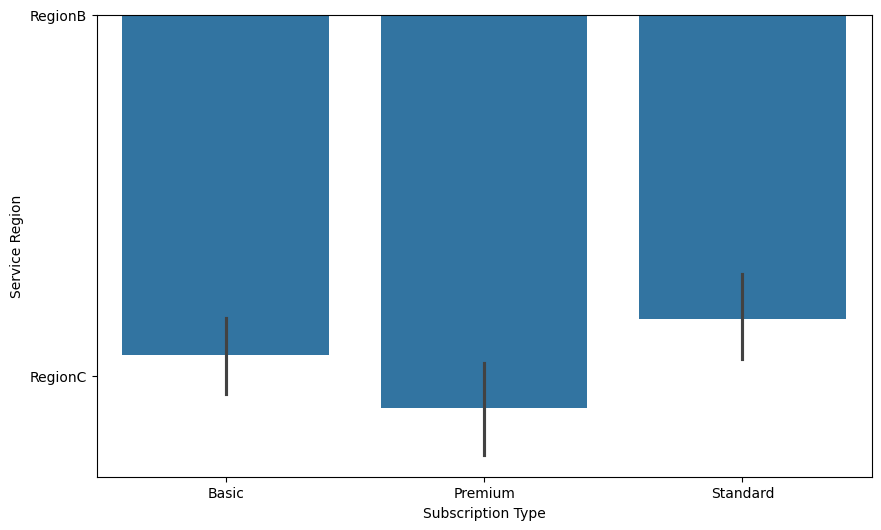

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='SubscriptionType', y='ServiceRegion')
plt.xlabel('Subscription Type')
plt.ylabel('Service Region')
plt.show()

## 7-6 | 이진 범주형 변수 조차 변환

### 【❓문제】
IsNewCustomer 컬럼을 True는 1로, False는 0으로 변환하는 코드를 작성하세요.

- astype(int) 함수를 사용하여 IsNewCustomer 컬럼의 값을 변환하고 df에 저장하세요.


In [41]:
df = df[df['IsNewCustomer'].astype(bool)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 10 to 598
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SubscriptionType         158 non-null    object 
 1   MonthlyCharges_USD       158 non-null    float64
 2   TotalUsage_GB            158 non-null    float64
 3   ContractDuration_Months  158 non-null    int64  
 4   ServiceRegion            158 non-null    object 
 5   IsNewCustomer            158 non-null    int64  
 6   Churn                    158 non-null    int64  
 7   CallCenterInteractions   158 non-null    int64  
 8   ComplaintCount           158 non-null    int64  
 9   TechSupportTickets       158 non-null    int64  
 10  PaymentIssues            158 non-null    int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 14.8+ KB


## 7-7 | 범주형 변수 원-핫 인코딩

### 【❓문제】
SubscriptionType과 ServiceRegion 컬럼을 원-핫 인코딩하세요.

- pandas의 get_dummies 함수를 활용하여 SubscriptionType과 ServiceRegion 컬럼에 대해 원-핫 인코딩을 수행하세요.

- 변경된 결과를 df_encoded 변수에 저장하세요.

In [42]:
df_encoded = pd.get_dummies(data=df, columns=['SubscriptionType', 'ServiceRegion'])

## 7-8 | 데이터 분리 및 스케일링

### 【❓문제】
특성 외로분리(Churn)를 예측하기 위해 데이터를 훈련 및 검증 데이터로 분리하고, 스케일링을 수행하세요.

- Churn 컬럼을 y 변수에, 나머지 컬럼들을 X 변수에 할당하세요.

- scikit-learn의 train_test_split 함수를 사용하여 X와 y를 훈련 데이터(80%)와 검증 데이터(20%)로 분할하세요. random_state는 42로 설정하세요.

- sklearn.preprocessing의 StandardScaler를 사용하여 훈련 데이터의 Feature(X_train)을 스케일링하고 X_train_scaled에 할당하세요.

- StandardScaler의 transform 함수를 사용하여 검증 데이터의 Feature(X_valid)를 스케일링하고 X_valid_scaled에 할당하세요.


In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

## 7-9 | 머신러닝 모델 학습(Logistic Regression)

### 【❓문제】
scikit-learn의 LogisticRegression 모델을 생성하고 학습하세요.

- 모델의 random_state는 42로 설정하세요.

- 모델을 logreg_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.


In [65]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(random_state=42)

logreg_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 7-10 | 머신러닝 모델 학습(Decision Tree)

### 【❓문제】
scikit-learn의 DecisionTreeClassifier 모델을 생성하고 학습하세요.

- 모델의 max_depth는 5, random_state는 42로 설정하세요.

- 모델을 dt_model 변수에 저장하고, 훈련 데이터(X_train, y_train)으로 학습을 진행하세요.

In [66]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 7-11 | 딥러닝 모델 개발 및 학습

### 【❓문제】
tensorflow.keras를 사용하여 고객 이탈 여부(Churn)를 예측하는 딥러닝 모델을 만들고 학습하세요.

- 은닉 레이어(Hidden Layer)를 2개로 구성하세요.

- 첫 번째 레이어는 32개, 두 번째는 16개의 뉴런을 가지도록 하세요.

- 모든 은닉 레이어에 relu 활성화 함수를 사용하고, 출력 레이어는 이진 분류이므로 sigmoid 활성화 함수를 사용하세요.

- 옵티마이저는 Adam을, 손실 함수는 이진 분류에 적합한 binary_crossentropy를 사용하세요.
- epochs는 30, batch_size는 32로 설정하고, 학습 진행 상황을 history 변수에 저장하세요.

In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

dl_model = Sequential([
    Input(shape=(X_train_scaled.shape[1], )),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = dl_model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_data=(X_valid_scaled, y_valid))

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3810 - loss: 0.8288 - val_accuracy: 0.3750 - val_loss: 0.8606
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3810 - loss: 0.7992 - val_accuracy: 0.3750 - val_loss: 0.8314
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3810 - loss: 0.7730 - val_accuracy: 0.3750 - val_loss: 0.8057
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3730 - loss: 0.7493 - val_accuracy: 0.3750 - val_loss: 0.7840
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3968 - loss: 0.7306 - val_accuracy: 0.4375 - val_loss: 0.7652
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4444 - loss: 0.7141 - val_accuracy: 0.4062 - val_loss: 0.7483
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5079 - loss: 0.7012 - val_accuracy: 0.4062 - val_loss: 0.7335
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5317 - loss: 0.6878 - val_accuracy: 0.4062 - val_loss: 0.7212


## 7-12 | 딥러닝 모델 학습 성능 시각화

### 【❓문제】
matplotlib을 활용하여 딥러닝 모델의 학습 정확도와 검증 정확도를 그래프로 표시하여 과적합을 추가하여 성능 변화를 시각화하세요.

- history 변수에 저장된 학습 정확도(accuracy)와 검증 정확도(val_accuracy)를 그래프로 그리세요.

- 각각의 라벨명은 'Training Accuracy'와 'Validation Accuracy'로 표시하세요.

- x축에 'Epochs', y축에 'Accuracy'라는 레이블을 지정하세요.

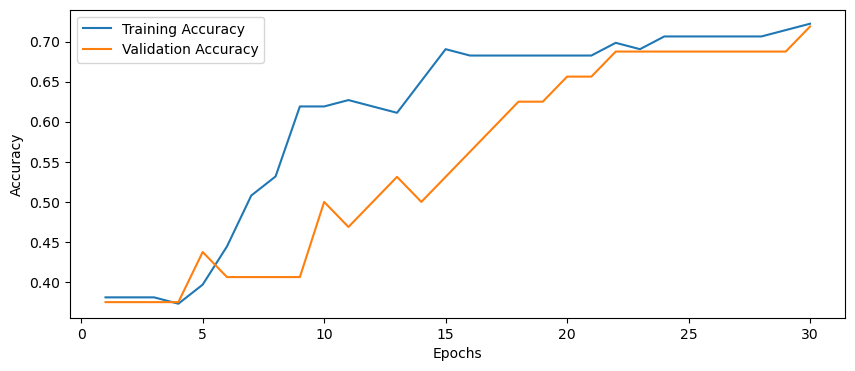

In [68]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(10,4))
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 7-13 | 최종 모델 성능 평가 및 결론 도출

### 【❓문제】
세 가지 모델(logreg_model, dt_model, model)의 성능을 검증 데이터(X를 활용하여 정확도(Accuracy)와 F1-score로 평가하고, 가장 우수한 성능을 보인 모델을 선택하세요.

- 각 모델을 사용하여 검증 데이터에서 대한 예측값을 생성하세요.

- scikit-learn의 accuracy_score와 f1_score 함수를 사용하여 각 모델의 성능을 평가하고 출력하세요.


In [70]:
logreg_pred = logreg_model.predict(X_valid_scaled)
dt_pred = dt_model.predict(X_valid_scaled)
dl_pred = dl_model.predict(X_valid_scaled).flatten()
dl_pred = (dl_pred > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score

logreg_as = accuracy_score(y_valid, logreg_pred)
dt_as = accuracy_score(y_valid, dt_pred)
dl_as = accuracy_score(y_valid, dl_pred)

logreg_f1 = f1_score(y_valid, logreg_pred)
dt_f1 = f1_score(y_valid, dt_pred)
dl_f1 = f1_score(y_valid, dl_pred)

print(f'Logistic Regressor - Accuracy Score : {logreg_as} | F1 Score : {logreg_f1}')
print(f'Decision Tree Classifier - Accuracy Score : {dt_as} | F1 Score : {dt_f1}')
print(f'Deep Learning Model - Accuracy Score : {dl_as} | F1 Score : {dl_f1}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Logistic Regressor - Accuracy Score : 0.625 | F1 Score : 0.45454545454545453
Decision Tree Classifier - Accuracy Score : 0.625 | F1 Score : 0.0
Deep Learning Model - Accuracy Score : 0.71875 | F1 Score : 0.47058823529411764


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
